# Library

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# 1. DATA

In [210]:
df = pd.read_csv("Country-data.csv", index_col=False)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# 2. Data Checking

### 2.1 NULL check

In [211]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# 3. EDA

## 1. Univariate

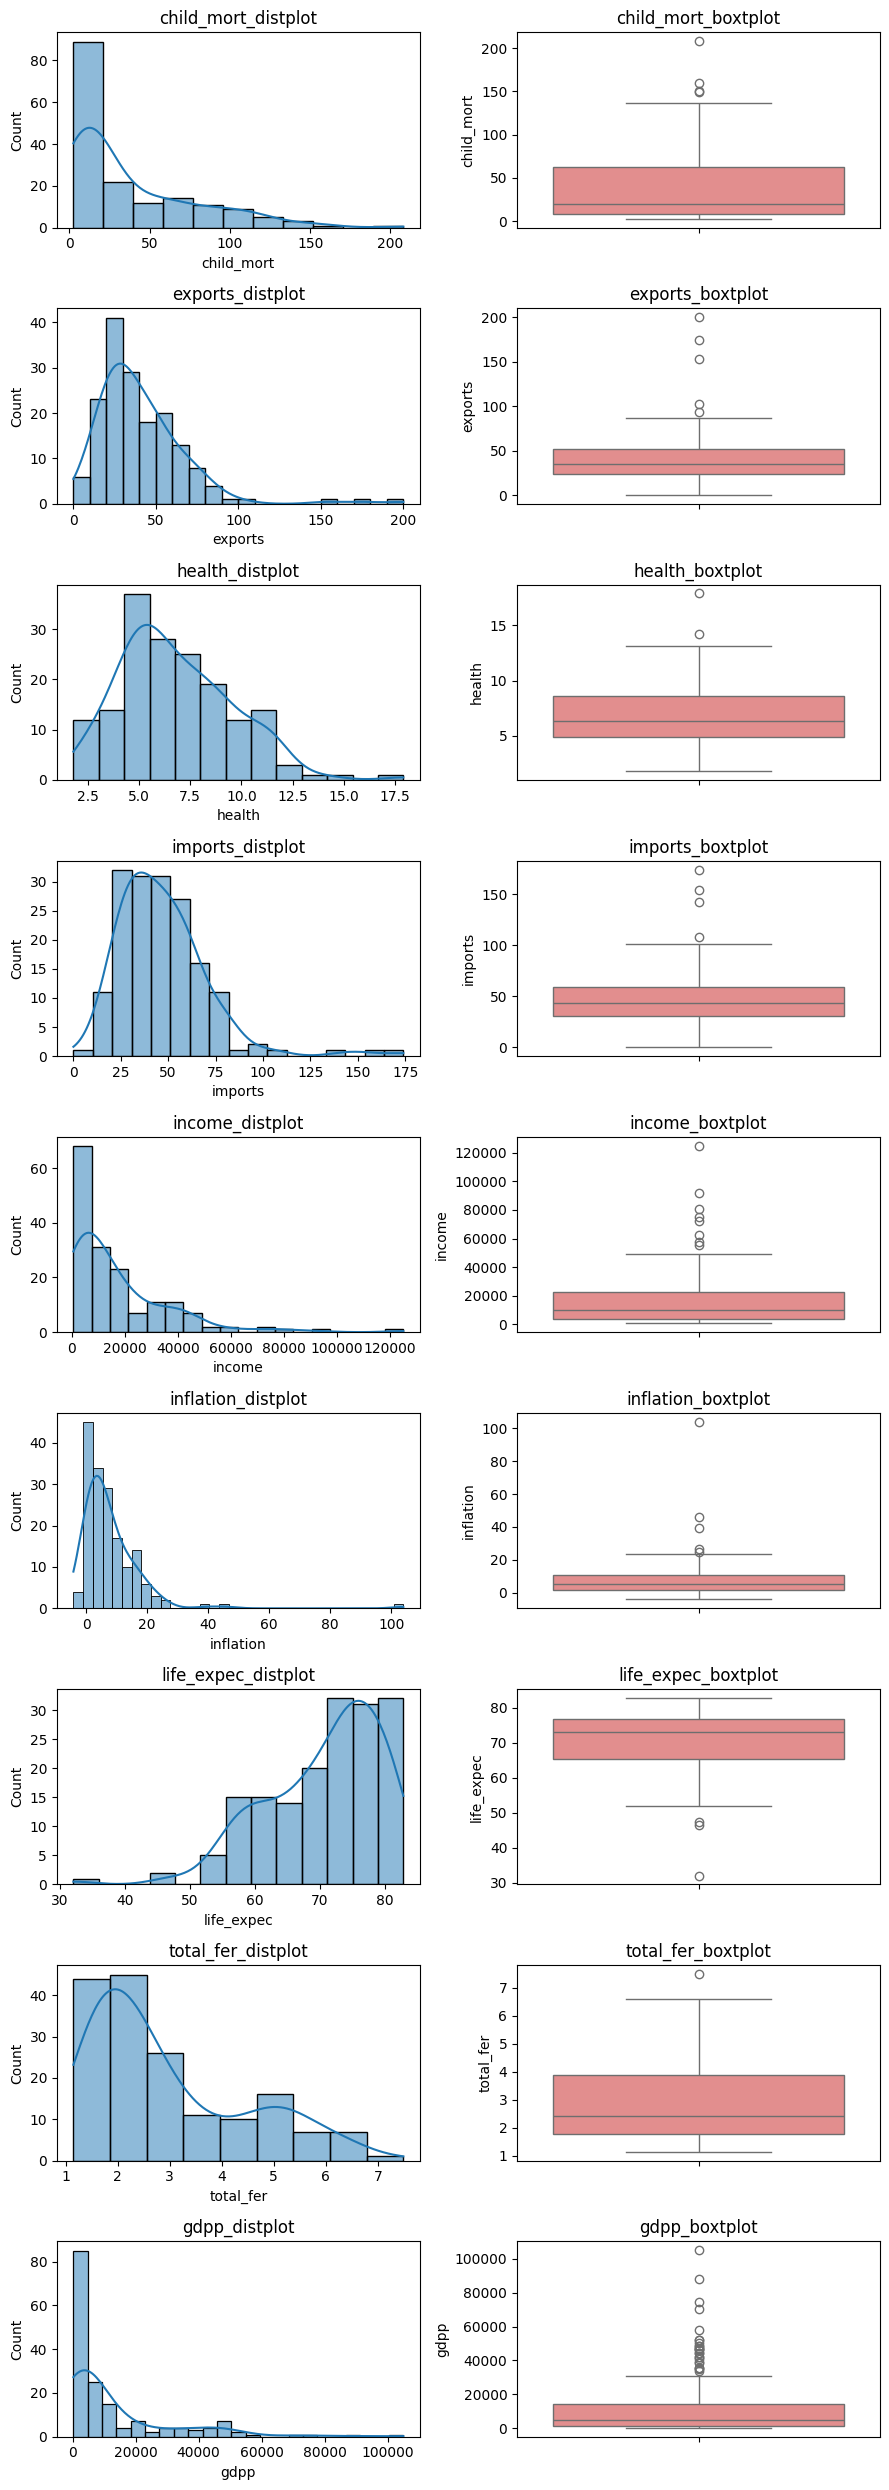

In [213]:
numeric_Col = [i for i in df.columns if i not in ['country']]

fig, axes = plt.subplots(len(numeric_Col), 2, figsize=(9,25))
for i, col in enumerate(numeric_Col):
    sns.histplot(df, x=col, ax=axes[i,0], kde=True)
    axes[i,0].set_title(f'{col}_distplot')
    
    sns.boxplot(df, y=col, ax=axes[i,1], color='lightcoral')
    axes[i,1].set_title(f'{col}_boxtplot')

plt.tight_layout()
plt.show()


**Insight**
- This dataset has quite a lot outliers in almost every column but we can't remove it will cause data loss our objective is to differentiate countrie is developed or not based on data 

### 3.2 Bivariate

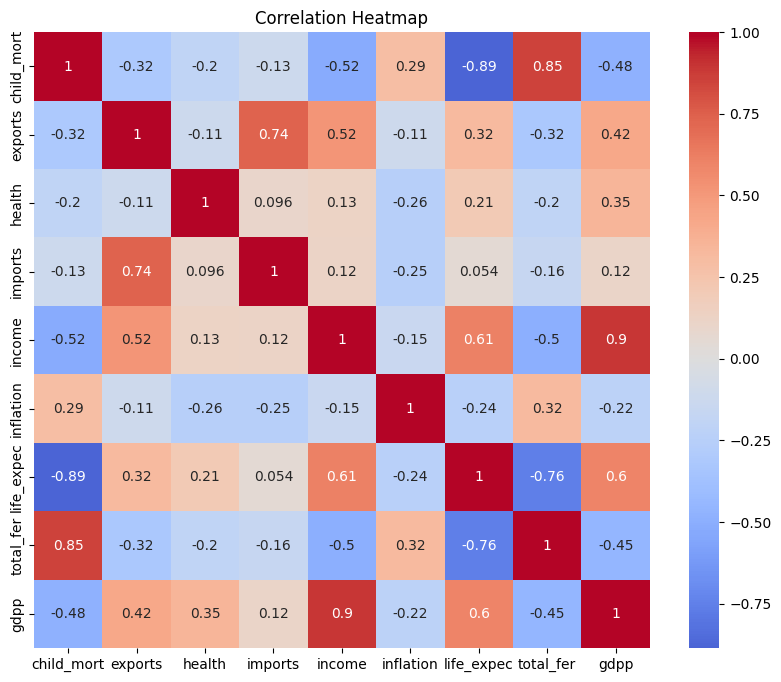

In [214]:
corr = df[numeric_Col].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, square=True)

plt.title("Correlation Heatmap")
plt.show()

In [215]:
corr[(corr>0.6) & (corr!=1)]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.848478,NaN
exports,NaN,NaN,NaN,0.737381,NaN,NaN,NaN,NaN,NaN
health,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imports,NaN,0.737381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,NaN,NaN,NaN,NaN,NaN,NaN,0.611962,NaN,0.895571
inflation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
life_expec,NaN,NaN,NaN,NaN,0.611962,NaN,NaN,NaN,0.600089
total_fer,0.848478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gdpp,NaN,NaN,NaN,NaN,0.895571,NaN,0.600089,NaN,NaN


**Insight**
- I can clearly see that GDP, Life_Expec and Income has the strong corr
- Health and infaltion has no corr with any column


**FEATURE I'm removed**
- child_mort as 0.84 corr with total_fer
- export and import are corr 0.737381
- income and gpd 0.89 corr

# 4. Scaling

## 4.1 Feature Scaling

I've used **RobustScaler** as i can't remove outliers so using standardScaler will cause issue but RobustScaler works better on outlier dataset.

In [216]:
df_eng = df.drop(columns = ['child_mort', 'imports', 'income']).copy()
numeric_Col = [i for i in numeric_Col if i not in ['child_mort', 'imports', 'income']] 
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(df_eng[numeric_Col])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_Col)

# 5 K Means

## 5.1 Elbow method

2 0.41590800675882317
3 0.26201082878993504
4 0.26124125668361303
5 0.27443013861289617
6 0.2880004628145105
7 0.2684591096023401
8 0.2690850402982583
9 0.22842044210351325


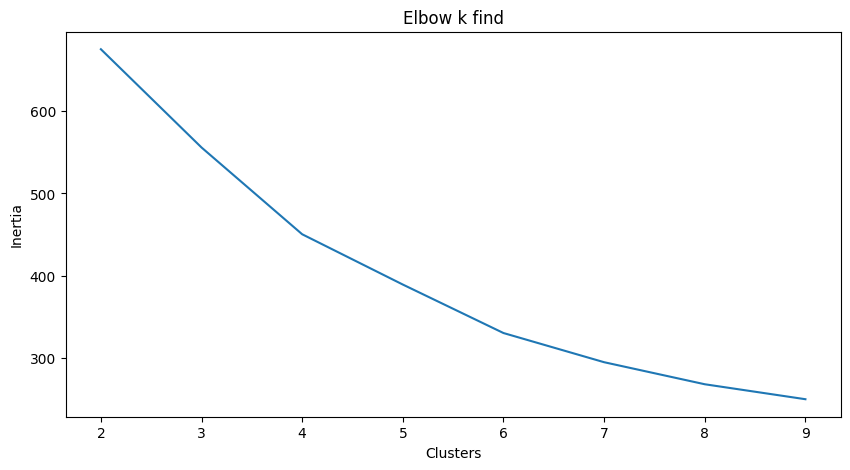

In [217]:
def elbow_mth(X_scaled):
    intr = []
    k_val = range(2,10)

    for k in k_val:
        k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
        k_means.fit(X_scaled)
        intr.append(k_means.inertia_)

        score = silhouette_score(X_scaled, k_means.fit_predict(X_scaled))
        print(k, score)

    plt.figure(figsize=(10, 5))
    plt.plot(list(k_val), intr)
    plt.title('Elbow k find')
    plt.xlabel('Clusters')
    plt.ylabel('Inertia')
    plt.show()
    
elbow_mth(X_scaled)

# 5.2 K Means on Elbow Setting

In [218]:
k = 2   # elbow methods states 4 but 2 get's is better silhouette_score
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
silhouette_score(X_scaled, kmeans.fit_predict(X_scaled))

0.41590800675882317

- 0.41 silhouette_score which is quite good 

# 6. Feature selection

- Since health and inflation had no corr with any other column either these are too important columns or it's making model weak

2 0.5040540622379543
3 0.39025088458373536
4 0.40117490284568863
5 0.3567868774770933
6 0.3656410120595369
7 0.34896795981613526
8 0.35019989504695703
9 0.3481114348702537


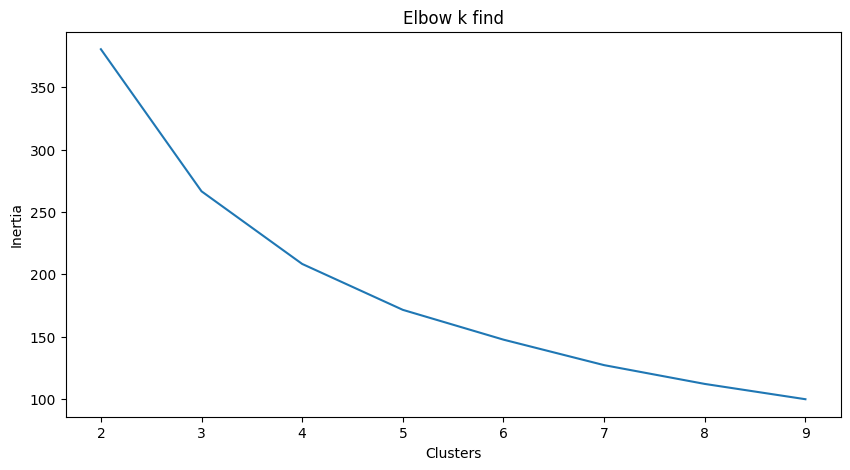

In [219]:
X_scaled_df_cp = X_scaled_df.drop(columns = ['health', 'inflation'])

# Elbow on dataset without ['health', 'inflation']
elbow_mth(X_scaled_df_cp)

# 6.1 Hit and trils on Top 3 columns

In [220]:
for col in X_scaled_df_cp.columns:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df_cp.drop(columns = col))
    score = silhouette_score(X_scaled_df_cp.drop(columns = col), kmeans.fit_predict(X_scaled_df_cp.drop(columns = col)))
    print(col,"removed:  ",score)

exports removed:   0.5873687501573213
life_expec removed:   0.5615358505131673
total_fer removed:   0.572922711282674
gdpp removed:   0.4367325556344209


When we remove Export columns it gives 0.58 score

# 6.2 Best K means on SELECTED FEATURE

2 0.5873687501573213
3 0.5280956090704942
4 0.5376611522573271
5 0.4396910383280494
6 0.41331228747635684
7 0.419252560344429
8 0.3763841213984607
9 0.35924255991877013


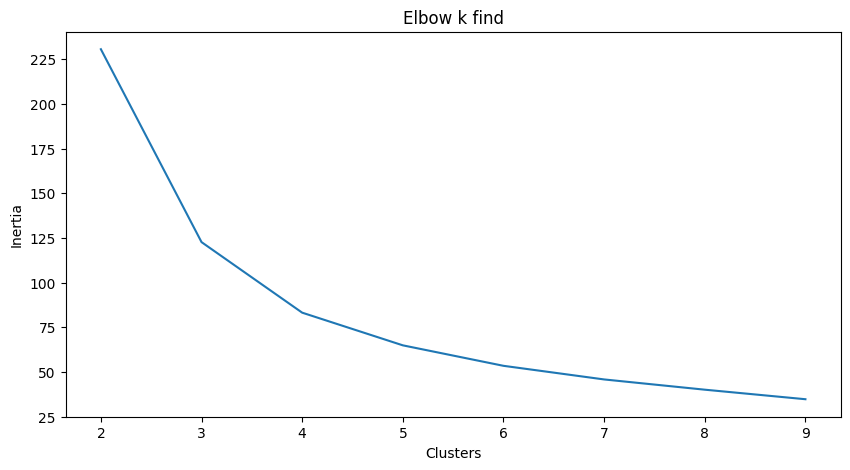

In [221]:
X_scaled_df_cp.drop(columns = ['exports'], inplace=True)
elbow_mth(X_scaled_df_cp)

In [222]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)  # Elbow states 3
kmeans.fit(X_scaled_df_cp)
silhouette_score(X_scaled_df_cp, kmeans.labels_)

0.5280956090704942

- Final Best silhouette_score is around 0.52 by kmeans

In [223]:
X_scaled_df_cp.columns

Index(['life_expec', 'total_fer', 'gdpp'], dtype='object')

## Labels count kmeans

In [224]:
pd.Series(kmeans.labels_).value_counts()

1    88
2    51
0    28
Name: count, dtype: int64

# 7. DBSCAN

In [225]:
dbscan = DBSCAN(eps=1.5, min_samples=8)
dbscan.fit(X_scaled_df_cp)
silhouette_score(X_scaled_df_cp, dbscan.fit_predict(X_scaled_df_cp))

0.6790181649452043

In [226]:
pd.Series(dbscan.labels_).value_counts()

 0    165
-1      2
Name: count, dtype: int64

Though silhouette_score 0.67 by DBscan is better than kmeans but the labels count clearly states that DBSCAN is lacking in making proper clusters

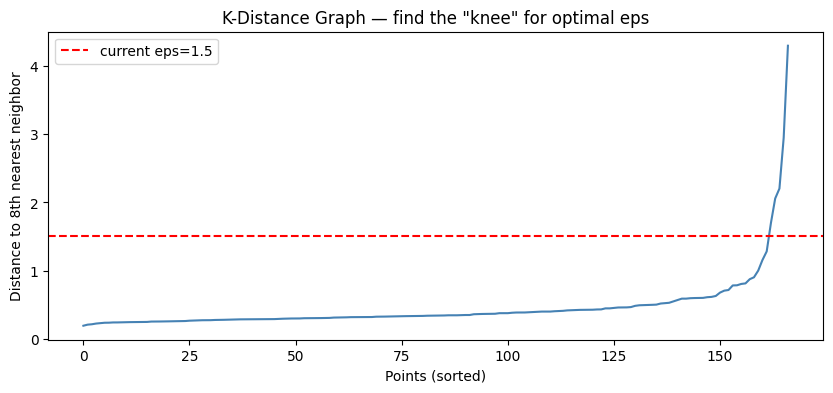

In [227]:
from sklearn.neighbors import NearestNeighbors

k = 8
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled_df_cp)
distances, _ = nbrs.kneighbors(X_scaled_df_cp)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(distances, color='steelblue')
plt.axhline(y=1.5, color='red', linestyle='--', label='current eps=1.5')
plt.title('K-Distance Graph — find the "knee" for optimal eps')
plt.xlabel('Points (sorted)')
plt.ylabel(f'Distance to {k}th nearest neighbor')
plt.legend()
plt.show()


# Elbow is around 1

In [228]:
dbscan = DBSCAN(eps=1, min_samples=2)
dbscan.fit(X_scaled_df_cp)
silhouette_score(X_scaled_df_cp, dbscan.fit_predict(X_scaled_df_cp))

0.6399988546130764

In [229]:
pd.Series(dbscan.labels_).value_counts()

 0    164
-1      3
Name: count, dtype: int64

- DBscan is not working well

# Prediction stored into DF

In [230]:
kmeans_cluster = kmeans.fit_predict(X_scaled_df_cp)
dbscan_cluster = dbscan.fit_predict(X_scaled_df_cp)

df['kmeans_cluster'] = kmeans_cluster
df['dbscan_cluster'] = dbscan_cluster

# PCA

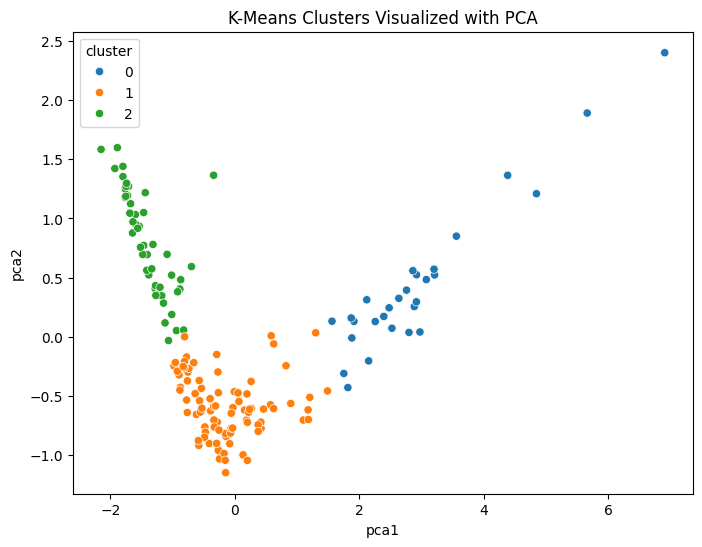

In [231]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df_cp)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

# Clustering

# 1. Which cluster has high child mortality?

<Axes: xlabel='kmeans_cluster'>

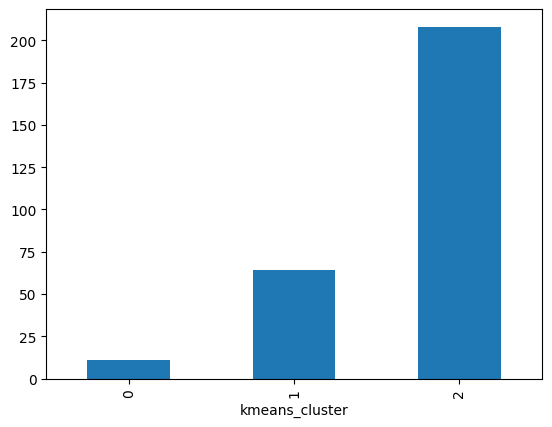

In [232]:
df.groupby('kmeans_cluster')['child_mort'].max().plot(kind='bar')

 - MAX is label 2 countries with highest child mortality 
- 1 is Avg
- 0 is Best

# 2. Which cluster has high income and gdpp?

<Axes: xlabel='kmeans_cluster'>

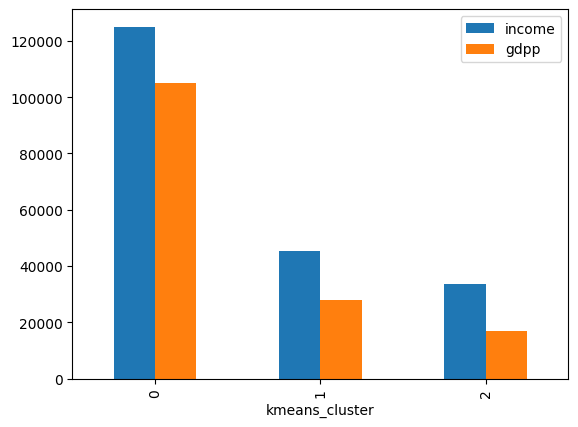

In [233]:
df.groupby('kmeans_cluster')[['income','gdpp']].max().plot(kind='bar')

- Label 0 countries has highest income and GDP
- Label 1 countries have Avg income and GDP comparitively
- Label 2 countries has the lowest income and GDP

# 3. Which cluster looks underdeveloped?

<Axes: xlabel='kmeans_cluster'>

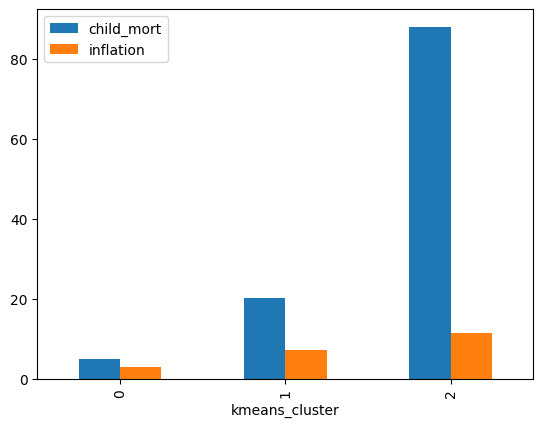

In [234]:
df.groupby("kmeans_cluster")[["child_mort","inflation"]].mean().plot(kind='bar')

- Label 2 countries are underdeveloped with highest inflation and child mort rate
- Label 1 are developing countries
- Label 0 are developed countries

# 4. Which countries should be prioritized for aid?

In [235]:
df[df["kmeans_cluster"]==0]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,dbscan_cluster
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,0,0
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,0,0
15,Belgium,4.5,76.4,10.70,74.7,41100,1.880,80.0,1.86,44400,0,0
23,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,0,0
29,Canada,5.6,29.1,11.30,31.0,40700,2.870,81.3,1.63,47400,0,0
42,Cyprus,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800,0,0
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000,0,0
53,Finland,3.0,38.7,8.95,37.4,39800,0.351,80.0,1.87,46200,0,0
54,France,4.2,26.8,11.90,28.1,36900,1.050,81.4,2.03,40600,0,0
58,Germany,4.2,42.3,11.60,37.1,40400,0.758,80.1,1.39,41800,0,0


# Conclusion

>> **Label 2 countries Require AID**
- K-means model
- columns: ['life_expec', 'total_fer', 'gdpp']
- K: 3 
**worked best 0.52 silhouette score**
- With k = 2 it gave better silhouette_score(0.58) but was marking most countries as under developed 
- when i tried k = 3 stated by Elbow it gave 3 classes developed, developing and under developed but it is accurate

DBSCAN is stating better silhouette_score(0.67) but it's unable to cluster and makeing 164 as under developed